In [24]:
import pandas as pd
import numpy as np
from pathlib import Path

# Project root
PROJECT_ROOT = Path.cwd().parent

# Dataset paths
TRANSACTION_PATH = PROJECT_ROOT / "data" / "raw" / "train_transaction.csv"
IDENTITY_PATH = PROJECT_ROOT / "data" / "raw" / "train_identity.csv"

# Load raw datasets
transaction_df = pd.read_csv(TRANSACTION_PATH)
identity_df = pd.read_csv(IDENTITY_PATH)

print("Transaction shape:", transaction_df.shape)
print("Identity shape:", identity_df.shape)

Transaction shape: (590540, 394)
Identity shape: (144233, 41)


In [3]:
# Basic dataset inspection

print("Transaction columns:")
print(transaction_df.columns.tolist())

print("\nIdentity columns:")
print(identity_df.columns.tolist())

print("\nTransaction data types:")
print(transaction_df.dtypes.value_counts())

print("\nIdentity data types:")
print(identity_df.dtypes.value_counts())

Transaction columns:
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V

In [2]:
# Analyze missing values

transaction_missing = transaction_df.isnull().sum()
identity_missing = identity_df.isnull().sum()

print("TRANSACTION DATASET - MISSING VALUES")
print("=" * 50)

transaction_missing = transaction_missing.sort_values(ascending=False)

print(transaction_missing.head(30))


print("\n\nIDENTITY DATASET - MISSING VALUES")
print("=" * 50)

identity_missing = identity_missing.sort_values(ascending=False)

print(identity_missing.head(30))

TRANSACTION DATASET - MISSING VALUES
dist2    552913
D7       551623
D13      528588
D14      528353
D12      525823
D6       517353
D9       515614
D8       515614
V153     508595
V149     508595
V141     508595
V146     508595
V154     508595
V162     508595
V142     508595
V158     508595
V161     508595
V157     508595
V138     508595
V139     508595
V148     508595
V140     508595
V155     508595
V156     508595
V147     508595
V163     508595
V143     508589
V145     508589
V144     508589
V165     508589
dtype: int64


IDENTITY DATASET - MISSING VALUES
id_24         139486
id_25         139101
id_07         139078
id_08         139078
id_21         139074
id_26         139070
id_23         139064
id_27         139064
id_22         139064
id_18          99120
id_04          77909
id_03          77909
id_33          70944
id_10          69307
id_09          69307
id_30          66668
id_32          66647
id_34          66428
id_14          64189
DeviceInfo     25567
id_13         

In [25]:
# ==========================================
# MISSING VALUE ANALYSIS
# ==========================================

# Transaction dataset
transaction_missing = pd.DataFrame({
    "Missing_Count": transaction_df.isnull().sum(),
    "Missing_Percentage": transaction_df.isnull().mean() * 100
})

transaction_missing = transaction_missing.sort_values(
    by="Missing_Percentage",
    ascending=False
)

print("TRANSACTION DATASET - MISSING VALUE ANALYSIS")
print("=" * 60)

display(transaction_missing.head(30))

TRANSACTION DATASET - MISSING VALUE ANALYSIS


,Missing_Count,Missing_Percentage
dist2,552913,93.628374
D7,551623,93.409930
D13,528588,89.509263
D14,528353,89.469469
D12,525823,89.041047
D6,517353,87.606767
D9,515614,87.312290
D8,515614,87.312290
V153,508595,86.123717
V149,508595,86.123717


In [26]:

# ============================================================
# MISSING VALUE ANALYSIS - IDENTITY DATASET
# ============================================================

identity_missing = (
    identity_df.isnull()
    .sum()
    .sort_values(ascending=False)
)

identity_missing_percentage = (
    identity_df.isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

identity_missing_table = pd.DataFrame({
    "Missing_Count": identity_missing,
    "Missing_Percentage": identity_missing_percentage
})

print("IDENTITY DATASET - MISSING VALUE ANALYSIS")
print("=" * 55)

display(identity_missing_table.head(30))


IDENTITY DATASET - MISSING VALUE ANALYSIS


,Missing_Count,Missing_Percentage
id_24,139486,96.708798
id_25,139101,96.441868
id_07,139078,96.425922
id_08,139078,96.425922
id_21,139074,96.423149
id_26,139070,96.420375
id_23,139064,96.416215
id_27,139064,96.416215
id_22,139064,96.416215
id_18,99120,68.722137


In [27]:
# ============================================================
# IDENTIFY HIGH-MISSING-VALUE COLUMNS
# ============================================================

TRANSACTION_THRESHOLD = 90
IDENTITY_THRESHOLD = 90

# Calculate missing percentages again
transaction_missing_percentage = (
    transaction_df.isnull().mean() * 100
)

identity_missing_percentage = (
    identity_df.isnull().mean() * 100
)

# Find columns above the threshold
transaction_high_missing = (
    transaction_missing_percentage[
        transaction_missing_percentage > TRANSACTION_THRESHOLD
    ]
    .sort_values(ascending=False)
)

identity_high_missing = (
    identity_missing_percentage[
        identity_missing_percentage > IDENTITY_THRESHOLD
    ]
    .sort_values(ascending=False)
)

# Display results
print("TRANSACTION DATASET")
print("=" * 60)
print(
    f"Columns with >{TRANSACTION_THRESHOLD}% missing values: "
    f"{len(transaction_high_missing)}"
)
display(transaction_high_missing.to_frame("Missing_Percentage"))

print("\nIDENTITY DATASET")
print("=" * 60)
print(
    f"Columns with >{IDENTITY_THRESHOLD}% missing values: "
    f"{len(identity_high_missing)}"
)
display(identity_high_missing.to_frame("Missing_Percentage"))

TRANSACTION DATASET
Columns with >90% missing values: 2


,Missing_Percentage
dist2,93.628374
D7,93.409930



IDENTITY DATASET
Columns with >90% missing values: 9


,Missing_Percentage
id_24,96.708798
id_25,96.441868
id_07,96.425922
id_08,96.425922
id_21,96.423149
id_26,96.420375
id_22,96.416215
id_23,96.416215
id_27,96.416215


In [28]:
# ============================================================
# INSPECT HIGH-MISSING-VALUE COLUMNS
# ============================================================

transaction_high_missing_cols = [
    "dist2",
    "D7"
]

identity_high_missing_cols = [
    "id_24",
    "id_25",
    "id_07",
    "id_08",
    "id_21",
    "id_26",
    "id_22",
    "id_23",
    "id_27"
]

print("TRANSACTION HIGH-MISSING COLUMNS")
print("=" * 60)

for col in transaction_high_missing_cols:
    print(
        f"{col}: "
        f"missing={transaction_df[col].isna().sum()}, "
        f"unique={transaction_df[col].nunique()}, "
        f"dtype={transaction_df[col].dtype}"
    )

print("\nIDENTITY HIGH-MISSING COLUMNS")
print("=" * 60)

for col in identity_high_missing_cols:
    print(
        f"{col}: "
        f"missing={identity_df[col].isna().sum()}, "
        f"unique={identity_df[col].nunique()}, "
        f"dtype={identity_df[col].dtype}"
    )

TRANSACTION HIGH-MISSING COLUMNS
dist2: missing=552913, unique=1751, dtype=float64
D7: missing=551623, unique=597, dtype=float64

IDENTITY HIGH-MISSING COLUMNS
id_24: missing=139486, unique=12, dtype=float64
id_25: missing=139101, unique=341, dtype=float64
id_07: missing=139078, unique=84, dtype=float64
id_08: missing=139078, unique=94, dtype=float64
id_21: missing=139074, unique=490, dtype=float64
id_26: missing=139070, unique=95, dtype=float64
id_22: missing=139064, unique=25, dtype=float64
id_23: missing=139064, unique=3, dtype=str
id_27: missing=139064, unique=2, dtype=str


In [29]:
# ============================================================
# STEP 1 - REMOVE HIGH-MISSING-VALUE COLUMNS
# ============================================================

# Create copies so the raw datasets remain untouched
transaction_clean = transaction_df.copy()
identity_clean = identity_df.copy()

# Columns identified for removal
transaction_drop_cols = [
    "dist2",
    "D7"
]

identity_drop_cols = [
    "id_24",
    "id_25",
    "id_07",
    "id_08",
    "id_21",
    "id_26",
    "id_22",
    "id_23",
    "id_27"
]

# Remove high-missing columns
transaction_clean = transaction_clean.drop(
    columns=transaction_drop_cols
)

identity_clean = identity_clean.drop(
    columns=identity_drop_cols
)

# Display results
print("CLEANING RESULT")
print("=" * 60)

print("Transaction dataset:")
print("Before:", transaction_df.shape)
print("After :", transaction_clean.shape)
print("Columns removed:", len(transaction_drop_cols))

print("\nIdentity dataset:")
print("Before:", identity_df.shape)
print("After :", identity_clean.shape)
print("Columns removed:", len(identity_drop_cols))

CLEANING RESULT
Transaction dataset:
Before: (590540, 394)
After : (590540, 392)
Columns removed: 2

Identity dataset:
Before: (144233, 41)
After : (144233, 32)
Columns removed: 9


In [30]:
# ==========================================
# TARGET VARIABLE ANALYSIS
# ==========================================

print("TARGET VARIABLE ANALYSIS")
print("=" * 60)

# Fraud distribution
fraud_counts = transaction_clean["isFraud"].value_counts()

print("\nFraud class counts:")
print(fraud_counts)

# Fraud percentage
fraud_percentage = transaction_clean["isFraud"].value_counts(normalize=True) * 100

print("\nFraud class percentage:")
print(fraud_percentage)

print("\nFraud distribution:")
print(f"Legitimate (0): {fraud_counts.get(0, 0):,} "
      f"({fraud_percentage.get(0, 0):.2f}%)")

print(f"Fraud (1):       {fraud_counts.get(1, 0):,} "
      f"({fraud_percentage.get(1, 0):.2f}%)")

TARGET VARIABLE ANALYSIS

Fraud class counts:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud class percentage:
isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64

Fraud distribution:
Legitimate (0): 569,877 (96.50%)
Fraud (1):       20,663 (3.50%)


In [31]:
# ==================================================
# DUPLICATE ROW ANALYSIS
# ==================================================

print("DUPLICATE ROW ANALYSIS")
print("=" * 60)

# Transaction dataset
transaction_duplicates = transaction_clean.duplicated().sum()

# Identity dataset
identity_duplicates = identity_clean.duplicated().sum()

print("Transaction dataset duplicate rows:", transaction_duplicates)
print("Identity dataset duplicate rows:", identity_duplicates)

DUPLICATE ROW ANALYSIS
Transaction dataset duplicate rows: 0
Identity dataset duplicate rows: 0


In [32]:
# ==================================================
# TRANSACTION ID OVERLAP ANALYSIS
# ==================================================

print("TRANSACTION ID OVERLAP ANALYSIS")
print("=" * 60)

transaction_ids = set(transaction_clean["TransactionID"])
identity_ids = set(identity_clean["TransactionID"])

common_ids = transaction_ids.intersection(identity_ids)

print("Transaction IDs:", len(transaction_ids))
print("Identity IDs:", len(identity_ids))
print("Common Transaction IDs:", len(common_ids))

print(
    "Identity records matched with transactions:",
    f"{len(common_ids) / len(transaction_ids) * 100:.2f}%"
)

TRANSACTION ID OVERLAP ANALYSIS
Transaction IDs: 590540
Identity IDs: 144233
Common Transaction IDs: 144233
Identity records matched with transactions: 24.42%


In [33]:
# ==================================================
# NUMERICAL FEATURE SUMMARY
# ==================================================

print("NUMERICAL FEATURE SUMMARY")
print("=" * 60)

numeric_features = [
    "TransactionAmt",
    "TransactionDT",
    "card1",
    "card2",
    "card3",
    "card5",
    "addr1",
    "dist1"
]

numeric_summary = transaction_clean[numeric_features].describe().T

numeric_summary["missing"] = transaction_clean[numeric_features].isnull().sum()

display(numeric_summary)

NUMERICAL FEATURE SUMMARY


,count,mean,std,min,25%,50%,75%,max,missing
TransactionAmt,590540.0,1.350272e+02,2.391625e+02,0.251,43.321,68.769,125.0,3.193739e+04,0
TransactionDT,590540.0,7.372311e+06,4.617224e+06,86400.000,3027057.750,7306527.500,11246620.0,1.581113e+07,0
card1,590540.0,9.898735e+03,4.901170e+03,1000.000,6019.000,9678.000,14184.0,1.839600e+04,0
card2,581607.0,3.625555e+02,1.577932e+02,100.000,214.000,361.000,512.0,6.000000e+02,8933
card3,588975.0,1.531949e+02,1.133644e+01,100.000,150.000,150.000,150.0,2.310000e+02,1565
card5,586281.0,1.992789e+02,4.124445e+01,100.000,166.000,226.000,226.0,2.370000e+02,4259
addr1,524834.0,2.907338e+02,1.017411e+02,100.000,204.000,299.000,330.0,5.400000e+02,65706
dist1,238269.0,1.185022e+02,3.718720e+02,0.000,3.000,8.000,24.0,1.028600e+04,352271


In [34]:
# ==================================================
# CATEGORICAL FEATURE ANALYSIS
# ==================================================

print("CATEGORICAL FEATURE ANALYSIS")
print("=" * 60)

categorical_features = [
    "ProductCD",
    "card4",
    "card6",
    "P_emaildomain",
    "R_emaildomain"
]

for col in categorical_features:
    print(f"\n{col}")
    print("-" * 40)
    print("Unique values:", transaction_clean[col].nunique(dropna=True))
    print("Missing values:", transaction_clean[col].isnull().sum())
    print("Top categories:")
    print(transaction_clean[col].value_counts(dropna=False).head(10))

CATEGORICAL FEATURE ANALYSIS

ProductCD
----------------------------------------
Unique values: 5
Missing values: 0
Top categories:
ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64

card4
----------------------------------------
Unique values: 4
Missing values: 1577
Top categories:
card4
visa                384767
mastercard          189217
american express      8328
discover              6651
NaN                   1577
Name: count, dtype: int64

card6
----------------------------------------
Unique values: 4
Missing values: 1571
Top categories:
card6
debit              439938
credit             148986
NaN                  1571
debit or credit        30
charge card            15
Name: count, dtype: int64

P_emaildomain
----------------------------------------
Unique values: 59
Missing values: 94456
Top categories:
P_emaildomain
gmail.com        228355
yahoo.com        100934
NaN               94456
hotmail.com       45250
anonymous.com    

In [35]:
# ==================================================
# FRAUD VS LEGITIMATE - TRANSACTION AMOUNT
# ==================================================

print("FRAUD VS LEGITIMATE - TRANSACTION AMOUNT")
print("=" * 60)

amount_by_fraud = transaction_clean.groupby("isFraud")["TransactionAmt"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

display(amount_by_fraud)

FRAUD VS LEGITIMATE - TRANSACTION AMOUNT


,count,mean,median,std,min,max
isFraud,,,,,,
0,569877,134.511665,68.5,239.395078,0.251,31937.391
1,20663,149.244779,75.0,232.212163,0.292,5191.000


<Figure size 1000x600 with 0 Axes>

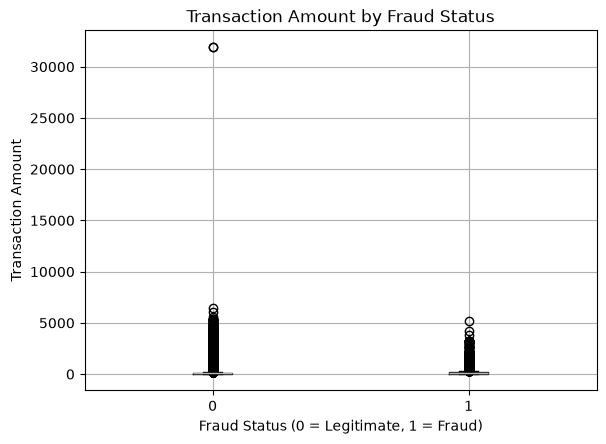

In [36]:
# ==================================================
# TRANSACTION AMOUNT DISTRIBUTION BY FRAUD STATUS
# ==================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

transaction_clean.boxplot(
    column="TransactionAmt",
    by="isFraud"
)

plt.title("Transaction Amount by Fraud Status")
plt.suptitle("")
plt.xlabel("Fraud Status (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()


In [37]:
# ==================================================
# FRAUD RATE BY PRODUCT CODE
# ==================================================

print("FRAUD RATE BY PRODUCT CODE")
print("=" * 60)

product_fraud = (
    transaction_clean
    .groupby("ProductCD")["isFraud"]
    .agg(["count", "sum", "mean"])
    .rename(columns={"sum": "fraud_count", "mean": "fraud_rate"})
)

product_fraud["fraud_rate"] = product_fraud["fraud_rate"] * 100

display(product_fraud.sort_values("fraud_rate", ascending=False))

FRAUD RATE BY PRODUCT CODE


,count,fraud_count,fraud_rate
ProductCD,,,
C,68519,8008,11.687269
S,11628,686,5.899553
H,33024,1574,4.766231
R,37699,1426,3.782594
W,439670,8969,2.039939


In [38]:
# ============================================================
# FRAUD RATE BY CATEGORICAL FEATURES
# ============================================================

categorical_features = [
    "card4",
    "card6",
    "P_emaildomain",
    "R_emaildomain"
]

for col in categorical_features:

    print("\n" + "=" * 60)
    print(f"FRAUD RATE BY {col}")
    print("=" * 60)

    fraud_rate = (
        transaction_clean
        .groupby(col, dropna=False)["isFraud"]
        .agg(["count", "sum", "mean"])
        .rename(columns={
            "sum": "fraud_count",
            "mean": "fraud_rate"
        })
    )

    fraud_rate["fraud_rate"] = fraud_rate["fraud_rate"] * 100

    fraud_rate = fraud_rate.sort_values(
        "fraud_rate",
        ascending=False
    )

    display(fraud_rate.head(15))


FRAUD RATE BY card4


,count,fraud_count,fraud_rate
card4,,,
discover,6651,514,7.728161
visa,384767,13373,3.475610
mastercard,189217,6496,3.433095
american express,8328,239,2.869837
NaN,1577,41,2.599873



FRAUD RATE BY card6


,count,fraud_count,fraud_rate
card6,,,
credit,148986,9950,6.678480
NaN,1571,39,2.482495
debit,439938,10674,2.426251
charge card,15,0,0.000000
debit or credit,30,0,0.000000



FRAUD RATE BY P_emaildomain


,count,fraud_count,fraud_rate
P_emaildomain,,,
protonmail.com,76,31,40.789474
mail.com,559,106,18.962433
outlook.es,438,57,13.013699
aim.com,315,40,12.698413
outlook.com,5096,482,9.458399
hotmail.es,305,20,6.557377
live.com.mx,749,41,5.473965
hotmail.com,45250,2396,5.295028
gmail.com,228355,9943,4.354185



FRAUD RATE BY R_emaildomain


,count,fraud_count,fraud_rate
R_emaildomain,,,
protonmail.com,41,39,95.121951
mail.com,122,46,37.704918
netzero.net,9,2,22.222222
outlook.com,2507,414,16.513761
outlook.es,433,57,13.163972
icloud.com,1398,180,12.875536
gmail.com,57147,6811,11.918386
hotmail.com,27509,2140,7.779272
earthlink.net,79,6,7.594937


In [39]:
# ============================================================
# FRAUD CORRELATION ANALYSIS
# ============================================================

print("TOP NUMERICAL FEATURES CORRELATED WITH FRAUD")
print("=" * 60)

# Select numerical columns
numeric_cols = transaction_clean.select_dtypes(
    include=["int64", "float64"]
).columns

# Calculate correlation with target
fraud_correlation = (
    transaction_clean[numeric_cols]
    .corr()["isFraud"]
    .drop("isFraud")
    .sort_values(key=abs, ascending=False)
)

display(
    fraud_correlation.head(20).to_frame("correlation_with_fraud")
)

TOP NUMERICAL FEATURES CORRELATED WITH FRAUD


,correlation_with_fraud
V257,0.383060
V246,0.366878
V244,0.364129
V242,0.360590
V201,0.328005
V200,0.318783
V189,0.308219
V188,0.303582
V258,0.297151
V45,0.281832


In [40]:
print("Transaction clean shape:", transaction_clean.shape)
print("Identity clean shape:", identity_clean.shape)


Transaction clean shape: (590540, 392)
Identity clean shape: (144233, 32)


In [41]:
# ============================================================
# MERGE TRANSACTION + IDENTITY DATA
# ============================================================

print("Before merge:")
print("Transaction:", transaction_clean.shape)
print("Identity:", identity_clean.shape)

# Merge identity information into transaction data
data = transaction_clean.merge(
    identity_clean,
    on="TransactionID",
    how="left"
)

print("\nAfter merge:")
print("Combined dataset:", data.shape)

print("\nTarget distribution:")
print(data["isFraud"].value_counts())

Before merge:
Transaction: (590540, 392)
Identity: (144233, 32)

After merge:
Combined dataset: (590540, 423)

Target distribution:
isFraud
0    569877
1     20663
Name: count, dtype: int64


In [42]:
# ============================================================
# FEATURE SELECTION - REMOVE IDENTIFIERS
# ============================================================

# Columns that should NOT be used as ML features
drop_columns = [
    "TransactionID"
]

# Separate target
X = data.drop(columns=["isFraud"] + drop_columns)
y = data["isFraud"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature data types:")
print(X.dtypes.value_counts())

Feature matrix shape: (590540, 421)
Target shape: (590540,)

Feature data types:
float64    390
str         29
int64        2
Name: count, dtype: int64


In [43]:
# ============================================================
# TRAIN / VALIDATION SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nValidation set:")
print("X_valid:", X_valid.shape)
print("y_valid:", y_valid.shape)

print("\nFraud percentage:")
print("Training:", y_train.mean() * 100)
print("Validation:", y_valid.mean() * 100)

Training set:
X_train: (472432, 421)
y_train: (472432,)

Validation set:
X_valid: (118108, 421)
y_valid: (118108,)

Fraud percentage:
Training: 3.498916246147594
Validation: 3.49933958749619


In [44]:
# ============================================================
# PREPROCESSING - REMOVE ID AND CREATE TIME FEATURES
# ============================================================

print("BEFORE PREPROCESSING")
print("Training shape:", X_train.shape)
print("Validation shape:", X_valid.shape)

# Remove TransactionID because it is only an identifier
if "TransactionID" in X_train.columns:
    X_train = X_train.drop(columns=["TransactionID"])
    X_valid = X_valid.drop(columns=["TransactionID"])

# Create time-based features from TransactionDT
if "TransactionDT" in X_train.columns:

    for df in [X_train, X_valid]:

        # Convert seconds into useful time-related features
        df["TransactionHour"] = (df["TransactionDT"] // 3600) % 24
        df["TransactionDay"] = df["TransactionDT"] // (3600 * 24)

    # Raw TransactionDT is not needed after extracting time features
    X_train = X_train.drop(columns=["TransactionDT"])
    X_valid = X_valid.drop(columns=["TransactionDT"])

print("\nAFTER PREPROCESSING")
print("Training shape:", X_train.shape)
print("Validation shape:", X_valid.shape)

print("\nRemaining categorical features:")
print(X_train.select_dtypes(include=["object"]).columns.tolist())

print("\nRemaining numerical features:", 
      len(X_train.select_dtypes(exclude=["object"]).columns))

print("Remaining categorical features:",
      len(X_train.select_dtypes(include=["object"]).columns))

BEFORE PREPROCESSING
Training shape: (472432, 421)
Validation shape: (118108, 421)

AFTER PREPROCESSING
Training shape: (472432, 422)
Validation shape: (118108, 422)

Remaining categorical features:
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']

Remaining numerical features: 393
Remaining categorical features: 29


C:\Users\Krushnarth\AppData\Local\Temp\ipykernel_10260\1599706310.py:32: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(X_train.select_dtypes(include=["object"]).columns.tolist())
C:\Users\Krushnarth\AppData\Local\Temp\ipykernel_10260\1599706310.py:38: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pyda

In [45]:
# ============================================================
# MISSING VALUE + CATEGORICAL PREPROCESSING
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify numerical and categorical columns
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

# Numerical preprocessing
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])

# Combine both pipelines
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("\nPreprocessor created successfully.")

Numerical features: 393
Categorical features: 29

Preprocessor created successfully.


C:\Users\Krushnarth\AppData\Local\Temp\ipykernel_10260\205085605.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [46]:
# ============================================================
# FIT PREPROCESSOR ON TRAINING DATA
# ============================================================

print("Fitting preprocessor on training data...")

# Fit ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform validation data using the same fitted preprocessor
X_valid_processed = preprocessor.transform(X_valid)

print("\nPREPROCESSING COMPLETE")
print("X_train processed shape:", X_train_processed.shape)
print("X_valid processed shape:", X_valid_processed.shape)

print("\nTarget shapes:")
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

Fitting preprocessor on training data...

PREPROCESSING COMPLETE
X_train processed shape: (472432, 2690)
X_valid processed shape: (118108, 2690)

Target shapes:
y_train: (472432,)
y_valid: (118108,)


In [47]:
# ==========================================
# BASELINE MODEL - LOGISTIC REGRESSION
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)
import time

print("Training Logistic Regression...")

start_time = time.time()

logistic_model = LogisticRegression(
    max_iter=50,
    solver="liblinear",
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)

training_time = time.time() - start_time

# Predictions
y_valid_pred = logistic_model.predict(X_valid_processed)
y_valid_prob = logistic_model.predict_proba(X_valid_processed)[:, 1]

# Metrics
precision = precision_score(y_valid, y_valid_pred)
recall = recall_score(y_valid, y_valid_pred)
f1 = f1_score(y_valid, y_valid_pred)
pr_auc = average_precision_score(y_valid, y_valid_prob)

print("\nLOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")
print(f"Training Time: {training_time:.2f} seconds")

Training Logistic Regression...


e:\PayGuard\venv\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



LOGISTIC REGRESSION RESULTS
Precision : 0.1488
Recall    : 0.7464
F1 Score  : 0.2481
PR-AUC    : 0.4611
Training Time: 585.32 seconds


In [48]:
# ==========================================
# MODEL 2 - RANDOM FOREST
# ==========================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)
import time

print("Training Random Forest...")

start_time = time.time()

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

random_forest_model.fit(X_train_processed, y_train)

training_time = time.time() - start_time

# Predictions
y_valid_rf_pred = random_forest_model.predict(X_valid_processed)
y_valid_rf_prob = random_forest_model.predict_proba(X_valid_processed)[:, 1]

# Metrics
rf_precision = precision_score(y_valid, y_valid_rf_pred)
rf_recall = recall_score(y_valid, y_valid_rf_pred)
rf_f1 = f1_score(y_valid, y_valid_rf_pred)
rf_pr_auc = average_precision_score(y_valid, y_valid_rf_prob)

print("\nRANDOM FOREST RESULTS")
print("=" * 50)
print(f"Precision      : {rf_precision:.4f}")
print(f"Recall         : {rf_recall:.4f}")
print(f"F1 Score       : {rf_f1:.4f}")
print(f"PR-AUC         : {rf_pr_auc:.4f}")
print(f"Training Time  : {training_time:.2f} seconds")

Training Random Forest...

RANDOM FOREST RESULTS
Precision      : 0.1716
Recall         : 0.7338
F1 Score       : 0.2782
PR-AUC         : 0.5213
Training Time  : 52.75 seconds


In [49]:
# ==========================================
# MODEL 3 - XGBOOST
# ==========================================

from xgboost import XGBClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)
import time

print("Training XGBoost...")

start_time = time.time()

xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric="logloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

xgb_model.fit(X_train_processed, y_train)

training_time = time.time() - start_time

# Predictions
y_valid_xgb_pred = xgb_model.predict(X_valid_processed)
y_valid_xgb_prob = xgb_model.predict_proba(X_valid_processed)[:, 1]

# Metrics
xgb_precision = precision_score(y_valid, y_valid_xgb_pred)
xgb_recall = recall_score(y_valid, y_valid_xgb_pred)
xgb_f1 = f1_score(y_valid, y_valid_xgb_pred)
xgb_pr_auc = average_precision_score(y_valid, y_valid_xgb_prob)

print("\nXGBOOST RESULTS")
print("=" * 50)
print(f"Precision      : {xgb_precision:.4f}")
print(f"Recall         : {xgb_recall:.4f}")
print(f"F1 Score       : {xgb_f1:.4f}")
print(f"PR-AUC         : {xgb_pr_auc:.4f}")
print(f"Training Time  : {training_time:.2f} seconds")

Training XGBoost...

XGBOOST RESULTS
Precision      : 0.2408
Recall         : 0.8137
F1 Score       : 0.3716
PR-AUC         : 0.6482
Training Time  : 26.55 seconds


In [50]:
# ==========================================
# THRESHOLD TUNING - XGBOOST
# ==========================================

import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:
    y_threshold_pred = (y_valid_xgb_prob >= threshold).astype(int)

    precision = precision_score(y_valid, y_threshold_pred, zero_division=0)
    recall = recall_score(y_valid, y_threshold_pred, zero_division=0)
    f1 = f1_score(y_valid, y_threshold_pred, zero_division=0)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

print("THRESHOLD RESULTS")
print("=" * 70)
display(threshold_df.round(4))

print("\nBEST THRESHOLD BY F1")
print("=" * 70)

best_row = threshold_df.loc[threshold_df["f1"].idxmax()]

print(f"Threshold : {best_row['threshold']:.2f}")
print(f"Precision : {best_row['precision']:.4f}")
print(f"Recall    : {best_row['recall']:.4f}")
print(f"F1 Score  : {best_row['f1']:.4f}")

THRESHOLD RESULTS


,threshold,precision,recall,f1
0,0.10,0.0508,0.9894,0.0966
1,0.15,0.0653,0.9736,0.1223
2,0.20,0.0837,0.9509,0.1538
3,0.25,0.1045,0.9250,0.1879
4,0.30,0.1273,0.9027,0.2231
5,0.35,0.1508,0.8781,0.2573
6,0.40,0.1772,0.8582,0.2937
7,0.45,0.2082,0.8389,0.3335
8,0.50,0.2408,0.8137,0.3716
9,0.55,0.2793,0.7880,0.4125



BEST THRESHOLD BY F1
Threshold : 0.85
Precision : 0.7245
Recall    : 0.5338
F1 Score  : 0.6147


In [52]:
# ==========================================
# THRESHOLD COMPARISON
# ==========================================

print("THRESHOLD COMPARISON")
print("=" * 60)

nearby = threshold_df[
    threshold_df["threshold"].round(2).isin([0.75, 0.80, 0.85, 0.90])
].copy()

display(nearby.round(4))

THRESHOLD COMPARISON


,threshold,precision,recall,f1
13,0.75,0.5279,0.6467,0.5813
14,0.80,0.6183,0.5974,0.6077
15,0.85,0.7245,0.5338,0.6147
16,0.90,0.8341,0.4612,0.5940


In [53]:
# ==========================================
# SAVE FINAL MODEL AND PREPROCESSOR
# ==========================================

import joblib
from pathlib import Path

# Create models directory
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

# Save final XGBoost model
model_path = MODELS_DIR / "fraud_model.pkl"
joblib.dump(xgb_model, model_path)

# Save fitted preprocessor
preprocessor_path = MODELS_DIR / "preprocessor.pkl"
joblib.dump(preprocessor, preprocessor_path)

print("ARTIFACTS SAVED")
print("=" * 50)
print(f"Model       : {model_path}")
print(f"Preprocessor: {preprocessor_path}")

ARTIFACTS SAVED
Model       : e:\PayGuard\models\fraud_model.pkl
Preprocessor: e:\PayGuard\models\preprocessor.pkl


In [55]:
# ==========================================
# EXACT MODEL INPUT FEATURES
# ==========================================

print("FINAL MODEL INPUT FEATURES")
print("=" * 60)

# Get the exact columns used when fitting the preprocessor
if hasattr(preprocessor, "feature_names_in_"):
    input_features = list(preprocessor.feature_names_in_)

    print(f"Total input features: {len(input_features)}")
    print()

    for i, feature in enumerate(input_features, 1):
        print(f"{i}. {feature}")

else:
    print("Preprocessor does not contain feature_names_in_.")
    print("\nPreprocessor transformers:")
    print(preprocessor.transformers_)

FINAL MODEL INPUT FEATURES
Total input features: 422

1. TransactionAmt
2. ProductCD
3. card1
4. card2
5. card3
6. card4
7. card5
8. card6
9. addr1
10. addr2
11. dist1
12. P_emaildomain
13. R_emaildomain
14. C1
15. C2
16. C3
17. C4
18. C5
19. C6
20. C7
21. C8
22. C9
23. C10
24. C11
25. C12
26. C13
27. C14
28. D1
29. D2
30. D3
31. D4
32. D5
33. D6
34. D8
35. D9
36. D10
37. D11
38. D12
39. D13
40. D14
41. D15
42. M1
43. M2
44. M3
45. M4
46. M5
47. M6
48. M7
49. M8
50. M9
51. V1
52. V2
53. V3
54. V4
55. V5
56. V6
57. V7
58. V8
59. V9
60. V10
61. V11
62. V12
63. V13
64. V14
65. V15
66. V16
67. V17
68. V18
69. V19
70. V20
71. V21
72. V22
73. V23
74. V24
75. V25
76. V26
77. V27
78. V28
79. V29
80. V30
81. V31
82. V32
83. V33
84. V34
85. V35
86. V36
87. V37
88. V38
89. V39
90. V40
91. V41
92. V42
93. V43
94. V44
95. V45
96. V46
97. V47
98. V48
99. V49
100. V50
101. V51
102. V52
103. V53
104. V54
105. V55
106. V56
107. V57
108. V58
109. V59
110. V60
111. V61
112. V62
113. V63
114. V64
115. V65

In [56]:
# ==========================================
# SAVE EXACT MODEL INPUT FEATURE LIST
# ==========================================

import json

features_path = PROJECT_ROOT / "models" / "model_input_features.json"

with open(features_path, "w") as f:
    json.dump(input_features, f, indent=4)

print("MODEL INPUT FEATURES SAVED")
print("=" * 60)
print(f"Total features: {len(input_features)}")
print(f"Saved to: {features_path}")

MODEL INPUT FEATURES SAVED
Total features: 422
Saved to: e:\PayGuard\models\model_input_features.json


In [57]:
# ==========================================
# VERIFY SAVED MODEL ARTIFACTS
# ==========================================

import joblib
import json

# Load artifacts
loaded_model = joblib.load(MODELS_DIR / "fraud_model.pkl")
loaded_preprocessor = joblib.load(MODELS_DIR / "preprocessor.pkl")

with open(MODELS_DIR / "model_input_features.json", "r") as f:
    loaded_features = json.load(f)

print("ARTIFACT VERIFICATION")
print("=" * 60)
print("Model loaded        :", type(loaded_model).__name__)
print("Preprocessor loaded :", type(loaded_preprocessor).__name__)
print("Input features      :", len(loaded_features))
print("Feature list valid  :", loaded_features == input_features)

ARTIFACT VERIFICATION
Model loaded        : XGBClassifier
Preprocessor loaded : ColumnTransformer
Input features      : 422
Feature list valid  : True


In [ ]:
# ==========================================
# FINAL MODEL PREDICTION TEST
# ==========================================

import numpy as np

# Take one real validation transaction
sample = X_valid.iloc[[0]]

# Transform using the saved preprocessor
sample_processed = preprocessor.transform(sample)

# Predict fraud probability
sample_probability = xgb_model.predict_proba(sample_processed)[0, 1]

# Apply selected threshold
best_threshold = 0.85
sample_prediction = int(sample_probability >= best_threshold)

print("FINAL MODEL TEST")
print("=" * 50)
print(f"Fraud Probability : {sample_probability:.4f}")
print(f"Threshold         : {best_threshold:.2f}")
print(f"Prediction        : {'FRAUD' if sample_prediction == 1 else 'NOT FRAUD'}")

FINAL MODEL TEST
Fraud Probability : 0.0735
Threshold         : 0.85
Prediction        : NOT FRAUD


: 